In [ ]:
import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset

from torchvision import transforms

from sklearn.model_selection import train_test_split

from google.colab import drive

import tarfile

DRIVE_PATH = '/content/drive'
DATASET_PATH = "/content/CUB_200_2011"

In [ ]:
def mount_drive():
  drive.mount(DRIVE_PATH)

In [ ]:
  def untar():
    archive = "/content/drive/MyDrive/birdproject/data/CUB_200_2011.tgz"
    extract_to = "/content/"

    with tarfile.open(archive, "r:gz") as tar:
        tar.extractall(path=extract_to, filter='data')


In [ ]:
if not os.path.isdir(DRIVE_PATH):
  mount_drive()

if not os.path.isdir(DATASET_PATH):
  untar()

images = pd.read_csv(
    os.path.join(DATASET_PATH, "images.txt"),
    sep=" ",
    names=["image_id", "filepath"]
)

labels = pd.read_csv(
    os.path.join(DATASET_PATH, "image_class_labels.txt"),
    sep=" ",
    names=["image_id", "class_id"]
)

split = pd.read_csv(
    os.path.join(DATASET_PATH, "train_test_split.txt"),
    sep=" ",
    names=["image_id", "is_train"]
)

classes = pd.read_csv(
    os.path.join(DATASET_PATH, "classes.txt"),
    sep=" ",
    names=["class_id", "class_name"]
)

df = images.merge(labels, on="image_id")
df = df.merge(split, on="image_id")

full_train_df = df[df["is_train"] == 1]
test_df = df[df["is_train"] == 0]


train_df, val_df = train_test_split(
    full_train_df,
    test_size=0.2,
    random_state=42,
    stratify=full_train_df["class_id"]
)



Mounted at /content/drive


In [ ]:
class BirdDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):

        self.data = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        img_path = os.path.join(
            self.root_dir,
            "images",
            row["filepath"]
        )

        image = Image.open(img_path).convert("RGB")

        label = row["class_id"] - 1

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = BirdDataset(
    train_df,
    DATASET_PATH,
    transform=train_transform
)

val_dataset = BirdDataset(
    val_df,
    DATASET_PATH,
    transform=test_transform
)

test_dataset = BirdDataset(
    test_df,
    DATASET_PATH,
    transform=test_transform
)

In [ ]:
from torch.utils.data import DataLoader


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))

image, label = train_dataset[0]

print(image.shape)
print(label)

print(train_df["class_id"].min(), train_df["class_id"].max())
print(val_df["class_id"].min(), val_df["class_id"].max())
print(test_df["class_id"].min(), test_df["class_id"].max())

4795
5794
1199
torch.Size([3, 224, 224])
61
1 200
1 200
1 200


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

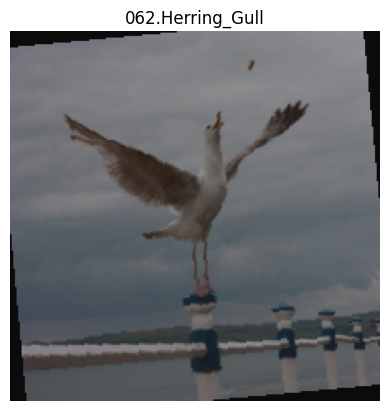

In [ ]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.permute(1,2,0))
plt.title(classes.iloc[label]["class_name"])
plt.axis("off")

In [ ]:
from torchvision.models import resnet18
import torch.nn as nn

model = resnet18(weights="DEFAULT")

model.fc = nn.Linear(model.fc.in_features, 200)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
import torch.optim as optim

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

In [ ]:
num_epochs = 30

best_val_acc = 0

for epoch in range(num_epochs):

    # ---------------------
    # Training
    # ---------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    scheduler.step()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # ---------------------
    # Validation
    # ---------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "best_bird_model.pth")
      print("Best model saved!")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Best model saved!
Epoch 1/30 | Train Loss: 4.6391 | Train Acc: 11.24% | Val Loss: 3.6539 | Val Acc: 29.61%
Best model saved!
Epoch 2/30 | Train Loss: 3.1563 | Train Acc: 44.63% | Val Loss: 2.7950 | Val Acc: 47.21%
Best model saved!
Epoch 3/30 | Train Loss: 2.2704 | Train Acc: 61.19% | Val Loss: 2.2066 | Val Acc: 52.71%
Best model saved!
Epoch 4/30 | Train Loss: 1.6598 | Train Acc: 73.60% | Val Loss: 1.8746 | Val Acc: 59.55%
Best model saved!
Epoch 5/30 | Train Loss: 1.2166 | Train Acc: 82.63% | Val Loss: 1.6461 | Val Acc: 62.39%
Best model saved!
Epoch 6/30 | Train Loss: 0.9192 | Train Acc: 86.80% | Val Loss: 1.4814 | Val Acc: 64.80%
Epoch 7/30 | Train Loss: 0.6824 | Train Acc: 90.97% | Val Loss: 1.4652 | Val Acc: 63.64%
Best model saved!
Epoch 8/30 | Train Loss: 0.5222 | Train Acc: 93.62% | Val Loss: 1.3992 | Val Acc: 65.47%
Best model saved!
Epoch 9/30 | Train Loss: 0.3770 | Train Acc: 95.95% | Val Loss: 1.3236 | Val Acc: 67.06%
Epoch 10/30 | Train Loss: 0.2828 | Train Acc: 97.46% | 

In [ ]:
model.load_state_dict(torch.load("best_bird_model.pth"))
model.to(device)
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)


test_loss /= len(test_loader)
test_acc = 100 * test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

KeyboardInterrupt: 

In [ ]:
from torchvision.models import resnet18
import torch.nn as nn

model = resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    200
)

model.load_state_dict(
    torch.load("/content/best_bird_model.pth", map_location=device)
)

model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from torchvision import transforms

inference_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
def predict_bird(image_path):

    image = Image.open(image_path).convert("RGB")

    image = inference_transform(image)
    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():

        output = model(image)

        probs = torch.softmax(output, dim=1)

        confidence, predicted = torch.max(probs, 1)

    species = class_names[predicted.item()]

    return species, confidence.item()

In [ ]:
class_names = classes["class_name"].tolist()

In [ ]:
species, confidence = predict_bird("/content/piccione.jpg")

print(species)
print(f"{confidence:.2%}")

108.White_necked_Raven
20.90%


In [ ]:
species, confidence = predict_bird("/content/gabbiano.jpg")

print(species)
print(f"{confidence:.2%}")

003.Sooty_Albatross
17.30%


In [ ]:
species, confidence = predict_bird("/content/tit.png")

print(species)
print(f"{confidence:.2%}")

091.Mockingbird
69.61%
